1. Import Necessary Librabries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, TimeSeriesSplit

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings("ignore")



2. Load Excel Data

In [3]:
file_path = "WHO_Cholera_Data_2026-01-26.xlsx"

#Read exel file 
df = pd.read_excel(file_path)


#Print fist five rows
df.head()

,Country,Year,WHO_Region,Total_Cases,Autochthonous_Cases,Imported_Cases,Deaths
0,Afghanistan,2000,EMRO,4330,4330,0,198
1,Afghanistan,2001,EMRO,4499,4499,0,114
2,Afghanistan,2002,EMRO,3,3,0,0
3,Afghanistan,2003,EMRO,41,41,0,7
4,Afghanistan,2005,EMRO,33,33,0,0


3. Do basic cleaning


In [4]:
import pandas as pd
import numpy as np

# 1. Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# 2. Handle missing values
# Check missing values
print("Missing values:\n", df.isnull().sum())

# Drop rows with missing total_cases
df = df.dropna(subset=["total_cases"])

# 3. Remove duplicate records
# Check duplicates
print("Duplicate rows:", df.duplicated().sum())

# Drop duplicates
df = df.drop_duplicates()

# Ensure uniqueness by country & year
df = df.drop_duplicates(subset=["country", "year"])

# 4. Fix data types
df["year"] = pd.to_numeric(df["year"], errors="coerce")
df["total_cases"] = pd.to_numeric(df["total_cases"], errors="coerce")

# 5. Sort data
df = df.sort_values(by=["country", "year"])


# 6. Detect outliers (IQR method)
Q1 = df["total_cases"].quantile(0.25)
Q3 = df["total_cases"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["total_cases"] < lower_bound) | (df["total_cases"] > upper_bound)]

df = df[(df["year"] >= 2010) & (df["year"] <= 2024)]

print("Outliers detected:\n", outliers)

# 7. Final check
print(df.head())
print("Final shape:", df.shape)


Missing values:
 country                0
year                   0
who_region             0
total_cases            0
autochthonous_cases    0
imported_cases         0
deaths                 0
dtype: int64
Duplicate rows: 0
Outliers detected:
           country  year who_region  total_cases  autochthonous_cases  \
11    Afghanistan  2014       EMRO        45481                45481   
12    Afghanistan  2015       EMRO        58064                58064   
17    Afghanistan  2022       EMRO       281485               281479   
18    Afghanistan  2023       EMRO       222249               222249   
20         Angola  2006       AFRO        67257                67257   
...           ...   ...        ...          ...                  ...   
1139     Zimbabwe  2008       AFRO        60055                60055   
1140     Zimbabwe  2009       AFRO        68153                68153   
1146     Zimbabwe  2018       AFRO        10692                10692   
1149     Zimbabwe  2023       AFRO   

4. West Africa Filtering

In [5]:
west_africa_countries = [
    "Benin", "Burkina Faso", "Cabo Verde", "Cape Verde",
    "Côte d'Ivoire", "Ivory Coast", "Gambia", "Ghana",
    "Guinea", "Guinea-Bissau", "Liberia", "Mali",
    "Niger", "Nigeria", "Senegal", "Sierra Leone", "Togo"
]

df_wa = df[df["country"].isin(west_africa_countries)].copy()

print("Filtered shape:", df_wa.shape)
print("Countries:", df_wa["country"].unique())

Filtered shape: (87, 7)
Countries: ['Benin' 'Burkina Faso' 'Ghana' 'Guinea' 'Guinea-Bissau' 'Liberia' 'Mali'
 'Niger' 'Nigeria' 'Senegal' 'Sierra Leone' 'Togo']


4.1 Total cases by West African country

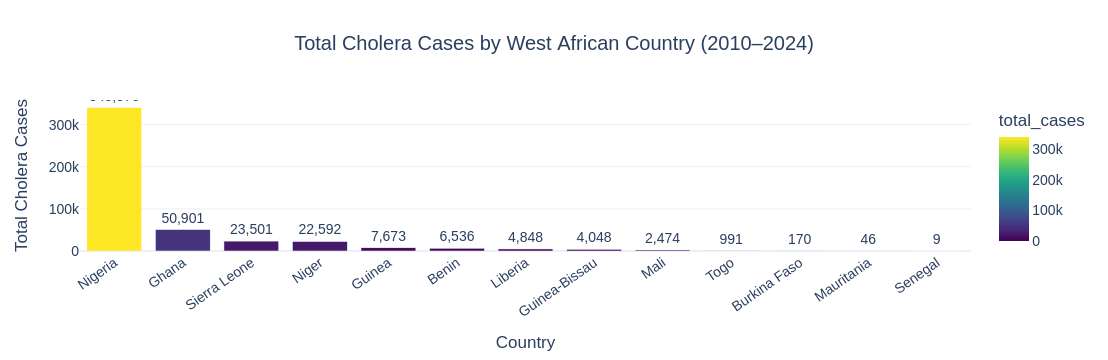

In [47]:
import pandas as pd
import plotly.express as px


df_wa = df[df["country"].isin(west_africa_countries)].copy()
df_wa = df_wa[(df_wa["year"] >= 2010) & (df_wa["year"] <= 2024)].copy()

country_cases = (
    df_wa.groupby("country", as_index=False)["total_cases"]
    .sum()
    .sort_values("total_cases", ascending=False)
)

fig = px.bar(
    country_cases,
    x="country",
    y="total_cases",
    color="total_cases",
    color_continuous_scale="Viridis",
    text="total_cases",
    title="Total Cholera Cases by West African Country (2010–2024)"
)

fig.update_traces(
    texttemplate="%{text:,.0f}",
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Country",
    yaxis_title="Total Cholera Cases",
    template="plotly_white",
    title_x=0.5,
    font=dict(size=14),
    coloraxis_colorbar=dict(title="total_cases")
)

fig.update_xaxes(tickangle=-35)
fig.update_yaxes(separatethousands=True)

fig.show()

5. Data Preprocessing

5.1 Data Scalling for LSTM

In [6]:
from sklearn.preprocessing import MinMaxScaler
west_africa_countries = [
    "Benin", "Burkina Faso", "Cabo Verde", "Cape Verde",
    "Côte d'Ivoire", "Ivory Coast", "Gambia", "Ghana",
    "Guinea", "Guinea-Bissau", "Liberia", "Mali",
    "Niger", "Nigeria", "Senegal", "Sierra Leone", "Togo"
]

df_wa = df[df["country"].isin(west_africa_countries)].copy()

# Aggregate West Africa data by year
yearly = df_wa.groupby("year")["total_cases"].sum().reset_index()


# Reshape data for scaling
values = yearly["total_cases"].values.reshape(-1, 1)

# Initialize scaler
scaler = MinMaxScaler(feature_range=(0, 1))

# Fit and transform
scaled_values = scaler.fit_transform(values)

print("Before scaling:\n", values[:5])
print("After scaling:\n", scaled_values[:5])

print(yearly.shape)
print(yearly.head())

Before scaling:
 [[48652]
 [40482]
 [50779]
 [ 9709]
 [68149]]
After scaling:
 [[0.40720498]
 [0.33754263]
 [0.42534106]
 [0.07515348]
 [0.57344816]]
(15, 2)
   year  total_cases
0  2010        48652
1  2011        40482
2  2012        50779
3  2013         9709
4  2014        68149


5.2 Disstribution of Annual Cholera Cases (Histogram)

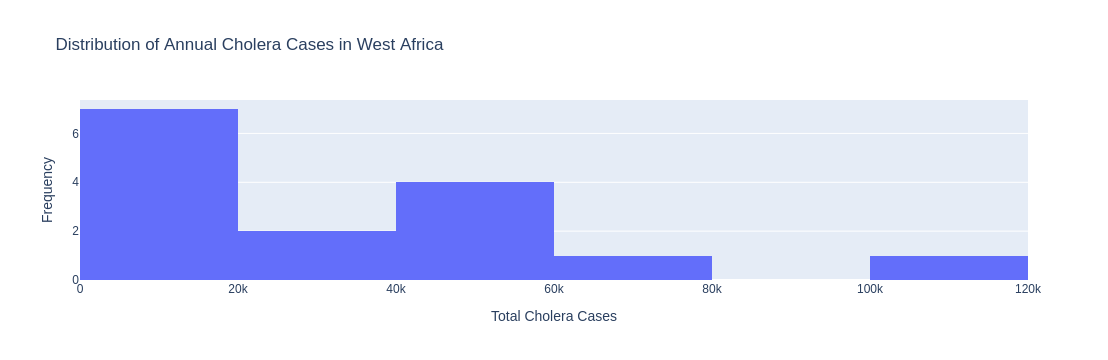

In [7]:
import plotly.express as px

fig = px.histogram(
    yearly,
    x="total_cases",
    nbins=10,
    title="Distribution of Annual Cholera Cases in West Africa"
)

fig.update_layout(
    xaxis_title="Total Cholera Cases",
    yaxis_title="Frequency"
)

fig.show()

5.3 Descriptive statistics

In [8]:
# Aggregate yearly data
df_year = df.groupby("year")["total_cases"].sum()

# Descriptive statistics
desc_stats = df_year.describe()

print(desc_stats)

count    1.500000e+01
mean     4.361977e+05
std      3.096429e+05
min      1.290670e+05
25%      2.069595e+05
50%      3.233690e+05
75%      5.480720e+05
max      1.227391e+06
Name: total_cases, dtype: float64


5.4 Distribution of Annual Cholera Cases (Box Plot)

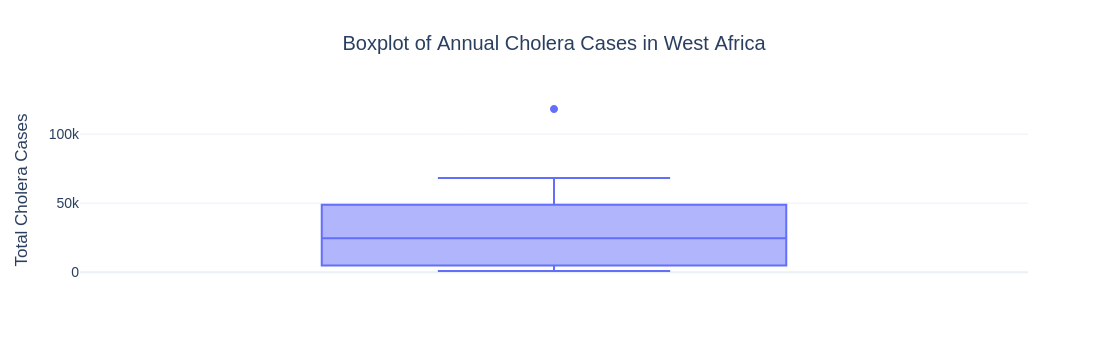

In [9]:
import plotly.express as px

fig = px.box(
    yearly,
    y="total_cases",
    points="outliers",  # show outliers clearly
    title="Boxplot of Annual Cholera Cases in West Africa"
)

fig.update_layout(
    yaxis_title="Total Cholera Cases",
    template="plotly_white",
    font=dict(size=14),
    title_x=0.5  # center title
)

fig.update_traces(
    marker=dict(size=8),
    line=dict(width=2)
)



fig.show()

5.5 Correlation

                     total_cases  autochthonous_cases  imported_cases  \
total_cases             1.000000             0.999996        0.001123   
autochthonous_cases     0.999996             1.000000       -0.001793   
imported_cases          0.001123            -0.001793        1.000000   
deaths                  0.964770             0.964750        0.006631   

                       deaths  
total_cases          0.964770  
autochthonous_cases  0.964750  
imported_cases       0.006631  
deaths               1.000000  


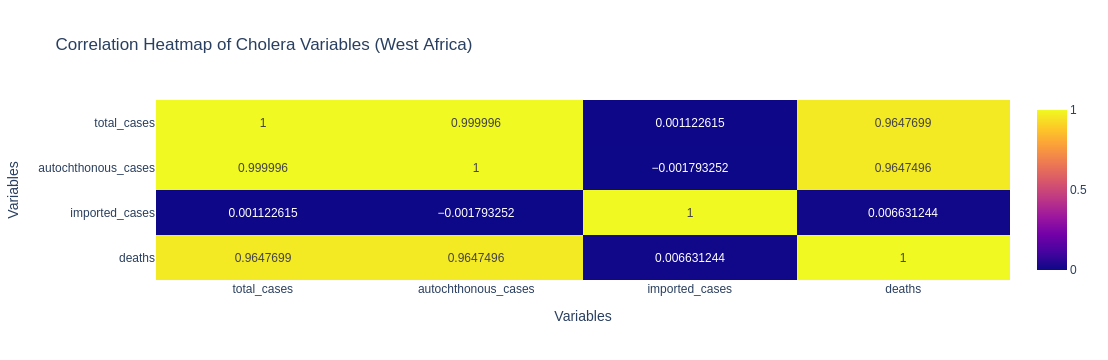

In [10]:
numeric_cols = [
    "total_cases",
    "autochthonous_cases",
    "imported_cases",
    "deaths"
]

#Correlation Matrix
corr_matrix = df_wa[numeric_cols].corr()

print(corr_matrix)

#Visualize
import plotly.express as px

fig = px.imshow(
    corr_matrix,
    text_auto=True,
    title="Correlation Heatmap of Cholera Variables (West Africa)",
    aspect="auto"
)

fig.update_layout(
    xaxis_title="Variables",
    yaxis_title="Variables"
)

fig.show()

5.6 Test for Normality in dataset

In [11]:
from scipy.stats import shapiro, skew, kurtosis

# Aggregate total cases per year
df_year = df.groupby("year")["total_cases"].sum()
data = df_year.values

# Shapiro-Wilk
stat, p = shapiro(data)
print("Shapiro-Wilk p-value:", p)

# Skewness
print("Skewness:", skew(data))

# Kurtosis
print("Kurtosis:", kurtosis(data))

Shapiro-Wilk p-value: 0.021432769802688923
Skewness: 1.2641571692023896
Kurtosis: 0.9843801296526369


5.7 Yearly trend

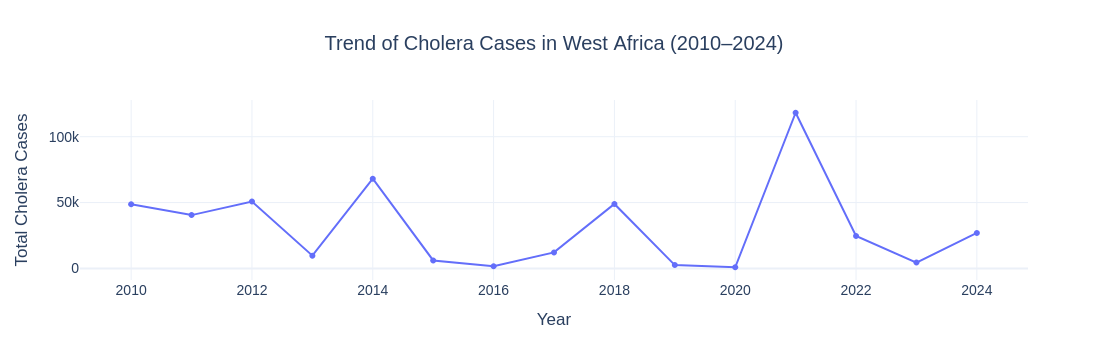

In [12]:
import plotly.express as px

# Step 1: Aggregate West Africa data by year
yearly = df_wa.groupby("year")["total_cases"].sum().reset_index()

# Step 2: Plot time series
fig = px.line(
    yearly,
    x="year",
    y="total_cases",
    markers=True,
    title="Trend of Cholera Cases in West Africa (2010–2024)"
)

fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Total Cholera Cases",
    template="plotly_white",
    title_x=0.5,
    font=dict(size=14)
)

fig.show()

5.8 Moving Average (Trend Solution)

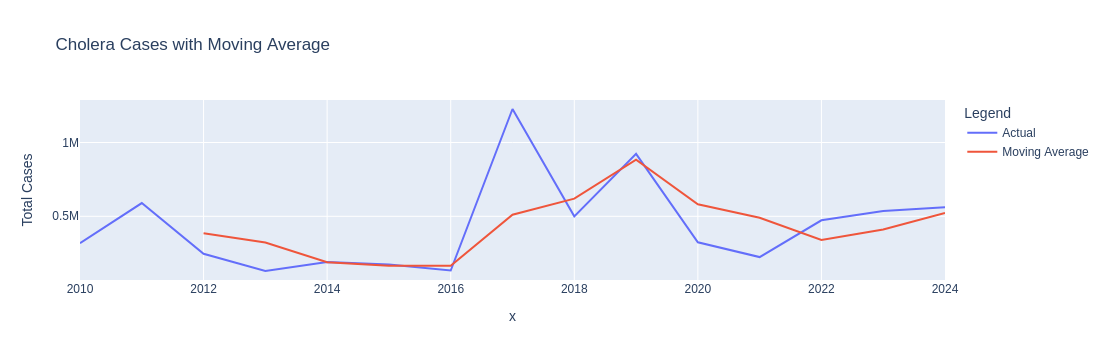

In [13]:
# Moving average (3-year window)
df_ma = df_year.rolling(window=3).mean()

fig = px.line(
    x=df_year.index,
    y=[df_year.values, df_ma.values],
    labels={"value": "Total Cases", "variable": "Legend"},
    title="Cholera Cases with Moving Average"
)


fig.data[0].name = "Actual"
fig.data[1].name = "Moving Average"

fig.show()

6.0 Data Splitting

6.1 Spilt dataset

In [14]:
df_year = df_wa.groupby("year", as_index=False)["total_cases"].sum()
years = yearly["year"].values
values = yearly["total_cases"].values

train_size = int(len(values) * 0.70)
val_size = int(len(values) * 0.15)

train_years = years[:train_size]
val_years = years[train_size:train_size + val_size]
test_years = years[train_size + val_size:]

train_values = values[:train_size]
val_values = values[train_size:train_size + val_size]
test_values = values[train_size + val_size:]

print("Training years:", train_years)
print("Validation years:", val_years)
print("Testing years:", test_years)

print("Train size:", len(train_values))
print("Validation size:", len(val_values))
print("Test size:", len(test_values))

Training years: [2010 2011 2012 2013 2014 2015 2016 2017 2018 2019]
Validation years: [2020 2021]
Testing years: [2022 2023 2024]
Train size: 10
Validation size: 2
Test size: 3


6.2 Visualize Data Split

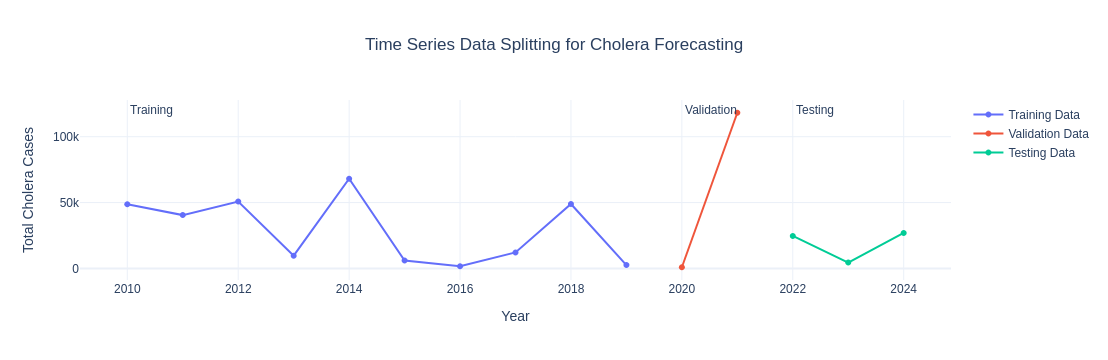

In [15]:
import plotly.graph_objects as go

fig = go.Figure()

# Training
fig.add_trace(go.Scatter(
    x=train_years,
    y=train_values,
    mode="lines+markers",
    name="Training Data"
))

# Validation
fig.add_trace(go.Scatter(
    x=val_years,
    y=val_values,
    mode="lines+markers",
    name="Validation Data"
))

# Testing
fig.add_trace(go.Scatter(
    x=test_years,
    y=test_values,
    mode="lines+markers",
    name="Testing Data"
))

# Shaded regions (KEY IMPROVEMENT)
fig.add_vrect(
    x0=train_years[0], x1=train_years[-1],
    opacity=0.08, line_width=0,
    annotation_text="Training", annotation_position="top left"
)

fig.add_vrect(
    x0=val_years[0], x1=val_years[-1],
    opacity=0.08, line_width=0,
    annotation_text="Validation", annotation_position="top left"
)

fig.add_vrect(
    x0=test_years[0], x1=test_years[-1],
    opacity=0.08, line_width=0,
    annotation_text="Testing", annotation_position="top left"
)

fig.update_layout(
    title="Time Series Data Splitting for Cholera Forecasting",
    xaxis_title="Year",
    yaxis_title="Total Cholera Cases",
    template="plotly_white",
    hovermode="x unified",
    title_x=0.5
)

fig.show()

7. Model Development

7.1 Function to compute rmse, mae and mape

In [16]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate(y_true, y_pred):

    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    return rmse, mae, mape

7.2 An array to append findings

In [17]:
tscv = TimeSeriesSplit(n_splits=5)

results = []

7.3 ARIMA Model

7.3.1 Generate Auto ARIMA 

In [18]:
from pmdarima import auto_arima
import pandas as pd

# Ensure df_wa exists
west_africa_countries = [
    "Benin", "Burkina Faso", "Cabo Verde", "Cape Verde",
    "Côte d'Ivoire", "Ivory Coast", "Gambia", "Ghana",
    "Guinea", "Guinea-Bissau", "Liberia", "Mali",
    "Niger", "Nigeria", "Senegal", "Sierra Leone", "Togo"
]

df_wa = df[df["country"].isin(west_africa_countries)].copy()

# Filter years
df_wa = df_wa[(df_wa["year"] >= 2010) & (df_wa["year"] <= 2024)]

# Aggregate yearly
df_year = df_wa.groupby("year", as_index=False)["total_cases"].sum()

# Convert to datetime index
df_year_arima = df_year.copy()
df_year_arima["year"] = pd.to_datetime(df_year_arima["year"], format="%Y")
df_year_arima = df_year_arima.set_index("year")

# Run auto ARIMA
auto_model = auto_arima(
    df_year_arima["total_cases"],
    start_p=0,
    start_q=0,
    max_p=5,
    max_q=5,
    max_d=2,
    seasonal=False,
    trace=True,
    stepwise=True,
    information_criterion="aic",
    error_action="ignore",
    suppress_warnings=True
)

print(auto_model.summary())
print("Selected order:", auto_model.order)

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=365.425, Time=0.07 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=365.636, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=366.219, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=363.655, Time=0.04 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=365.070, Time=0.04 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=364.135, Time=0.11 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=368.794, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=366.951, Time=0.01 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=369.802, Time=0.05 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=361.055, Time=0.04 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=358.101, Time=0.04 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=357.276, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=358.523, Time=0.02 sec

Best model:  ARIMA(0,0,0)(0,0,0)[0] intercept
Total fit time: 0.509 seconds
                               SARI

7.3.2 Compute ARIMA Model

In [19]:
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.arima.model import ARIMA

# Make sure df_year is in the right form
if isinstance(df_year, pd.Series):
    y = df_year.values
else:
    y = df_year["total_cases"].values

# Use the order selected by auto_arima
selected_order = auto_model.order
print("Selected ARIMA order:", selected_order)

# Initialize results list if needed
if "results" not in globals():
    results = []

arima_rmse, arima_mae, arima_mape = [], [], []

tscv = TimeSeriesSplit(n_splits=5)

for train_idx, test_idx in tscv.split(y):
    train, test = y[train_idx], y[test_idx]

    model = ARIMA(train, order=selected_order)
    fitted_model = model.fit()

    preds = fitted_model.forecast(steps=len(test))

    rmse, mae, mape = evaluate(test, preds)

    arima_rmse.append(rmse)
    arima_mae.append(mae)
    arima_mape.append(mape)

results.append([
    "ARIMA",
    np.mean(arima_rmse),
    np.mean(arima_mae),
    np.mean(arima_mape)
])

print("ARIMA Results:")
print("RMSE:", np.mean(arima_rmse))
print("MAE:", np.mean(arima_mae))
print("MAPE:", np.mean(arima_mape))

Selected ARIMA order: (0, 0, 0)
ARIMA Results:
RMSE: 34830.34806470887
MAE: 30510.715318615938
MAPE: 859.4457402026248


7.4 Random Forest

In [20]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# Use year column (NOT index)
X = df_year["year"].values.reshape(-1, 1)

# Target
y = df_year["total_cases"].values

rf_rmse, rf_mae, rf_mape = [], [], []

tscv = TimeSeriesSplit(n_splits=5)

for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    rf_model = RandomForestRegressor(
        n_estimators=200,
        random_state=42
    )

    rf_model.fit(X_train, y_train)

    preds = rf_model.predict(X_test)

    rmse, mae, mape = evaluate(y_test, preds)

    rf_rmse.append(rmse)
    rf_mae.append(mae)
    rf_mape.append(mape)

results.append([
    "Random Forest",
    np.mean(rf_rmse),
    np.mean(rf_mae),
    np.mean(rf_mape)
])

print("Random Forest Results:")
print("RMSE:", np.mean(rf_rmse))
print("MAE:", np.mean(rf_mae))
print("MAPE:", np.mean(rf_mape))

Random Forest Results:
RMSE: 45991.491125494555
MAE: 41381.544
MAPE: 1048.5797564026218


7.5 LSTM Model

In [21]:
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
import pandas as pd


# Prepare annual series
y_series = df_year["total_cases"].values.reshape(-1, 1)

# Define sequence length
sequence_length = 2

# Initialize results list if not already created
if "results" not in globals():
    results = []

lstm_rmse, lstm_mae, lstm_mape = [], [], []

tscv = TimeSeriesSplit(n_splits=5)

for train_idx, test_idx in tscv.split(y_series):
    train, test = y_series[train_idx], y_series[test_idx]

    # Scale training and testing separately based on training fit
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(train)
    test_scaled = scaler.transform(test)

    # Sequence generator for training
    generator = TimeseriesGenerator(
        train_scaled,
        train_scaled,
        length=sequence_length,
        batch_size=1
    )

    # Build LSTM model
    model = Sequential()
    model.add(LSTM(50, activation="relu", input_shape=(sequence_length, 1)))
    model.add(Dense(1))
    model.compile(optimizer="adam", loss="mse")

    # Train model
    model.fit(generator, epochs=100, verbose=0)

    # Predict iteratively on test set
    preds_scaled = []
    current_seq = train_scaled[-sequence_length:].copy()

    for _ in range(len(test_scaled)):
        pred_scaled = model.predict(current_seq.reshape(1, sequence_length, 1), verbose=0)
        preds_scaled.append(pred_scaled[0, 0])

        # update sequence
        current_seq = np.vstack([current_seq[1:], pred_scaled])

    preds_scaled = np.array(preds_scaled).reshape(-1, 1)

    # Inverse transform predictions back to original scale
    preds = scaler.inverse_transform(preds_scaled).flatten()
    actual = test.flatten()

    rmse, mae, mape = evaluate(actual, preds)

    lstm_rmse.append(rmse)
    lstm_mae.append(mae)
    lstm_mape.append(mape)

results.append([
    "LSTM",
    np.mean(lstm_rmse),
    np.mean(lstm_mae),
    np.mean(lstm_mape)
])

print("LSTM Results:")
print("RMSE:", np.mean(lstm_rmse))
print("MAE:", np.mean(lstm_mae))
print("MAPE:", np.mean(lstm_mape))

2026-04-13 07:39:32.706570: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


LSTM Results:
RMSE: 33398.149001930025
MAE: 28424.853515625
MAPE: 798.3206123179098


7.6 Converrting results to dataframe

In [22]:
results_df = pd.DataFrame(results, columns=["Model", "RMSE", "MAE", "MAPE"])
print(results_df)

           Model          RMSE           MAE         MAPE
0          ARIMA  34830.348065  30510.715319   859.445740
1  Random Forest  45991.491125  41381.544000  1048.579756
2           LSTM  33398.149002  28424.853516   798.320612


8.0 SHAP Analysis

8.1 Biuld Random Forest for SHAP Analysis

In [23]:
from sklearn.ensemble import RandomForestRegressor

X_shap = df_wa[["year", "deaths", "imported_cases", "autochthonous_cases"]].copy()
y_shap = df_wa["total_cases"].copy()

rf_shap_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_shap_model.fit(X_shap, y_shap)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


8.2 Running SHAP

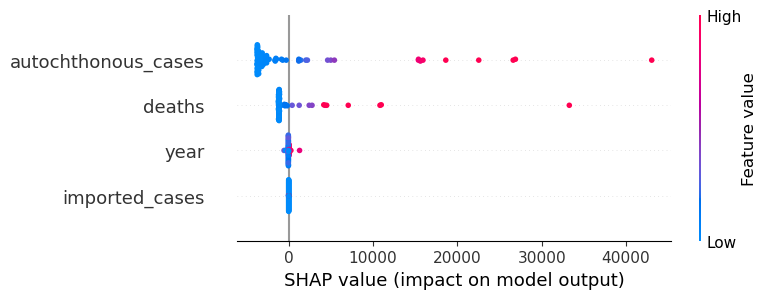

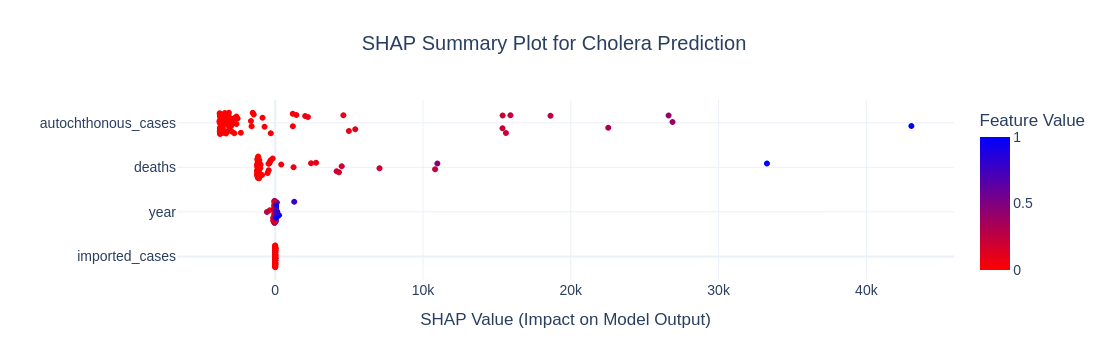

In [24]:
import shap
import numpy as np
import pandas as pd
import plotly.express as px

# SHAP explainer using the interpretability model
explainer = shap.Explainer(rf_shap_model, X_shap)

# Compute SHAP values
shap_values = explainer(X_shap)

# Optional: standard SHAP summary plot
shap.summary_plot(shap_values, X_shap)

# SHAP values matrix
shap_matrix = shap_values.values

# Feature names
features = X_shap.columns.tolist()

# Compute feature importance for ordering
mean_abs_shap = np.abs(shap_matrix).mean(axis=0)

importance_df = pd.DataFrame({
    "Feature": features,
    "MeanAbsSHAP": mean_abs_shap
}).sort_values("MeanAbsSHAP", ascending=False)

# Reorder features by importance
ordered_features = importance_df["Feature"].tolist()

# Build long-format dataframe for Plotly
plot_data = []

for feature in ordered_features:
    feature_idx = X_shap.columns.get_loc(feature)
    shap_feature_vals = shap_matrix[:, feature_idx]
    raw_feature_vals = X_shap[feature].values

    # Normalize feature values for coloring
    fmin, fmax = raw_feature_vals.min(), raw_feature_vals.max()
    if fmax - fmin == 0:
        color_vals = np.zeros_like(raw_feature_vals, dtype=float)
    else:
        color_vals = (raw_feature_vals - fmin) / (fmax - fmin)

    # Add slight vertical jitter for beeswarm effect
    jitter = np.random.uniform(-0.25, 0.25, size=len(shap_feature_vals))

    for i in range(len(shap_feature_vals)):
        plot_data.append({
            "Feature": feature,
            "SHAP Value": shap_feature_vals[i],
            "Feature Value": raw_feature_vals[i],
            "Color Value": color_vals[i],
            "Jitter": jitter[i]
        })

plot_df = pd.DataFrame(plot_data)

# Map feature names to numeric y positions
feature_to_num = {feat: i for i, feat in enumerate(reversed(ordered_features))}
plot_df["y_num"] = plot_df["Feature"].map(feature_to_num) + plot_df["Jitter"]

# Plotly scatter beeswarm
fig = px.scatter(
    plot_df,
    x="SHAP Value",
    y="y_num",
    color="Color Value",
    color_continuous_scale="Bluered_r",
    hover_data={
        "Feature": True,
        "SHAP Value": ":.3f",
        "Feature Value": ":.3f",
        "Color Value": False,
        "y_num": False,
        "Jitter": False
    },
    title="SHAP Summary Plot for Cholera Prediction"
)

# Format y-axis to show feature names
fig.update_yaxes(
    tickmode="array",
    tickvals=list(feature_to_num.values()),
    ticktext=list(reversed(ordered_features)),
    title="Features"
)

fig.update_layout(
    xaxis_title="SHAP Value (Impact on Model Output)",
    yaxis_title="",
    template="plotly_white",
    title_x=0.5,
    font=dict(size=14),
    coloraxis_colorbar=dict(title="Feature Value")
)

fig.show()

9. Models Forecast 

9.1 ARIMA Forecast

In [31]:
import pandas as pd
import numpy as np

# Forecast next 3 years with fitted ARIMA model
n_periods = 3

arima_forecast, arima_conf_int = auto_model.predict(
    n_periods=n_periods,
    return_conf_int=True
)

# Future years
future_years = [2025, 2026, 2027]

# Store results in a table
arima_forecast_df = pd.DataFrame({
    "year": future_years,
    "ARIMA Forecast": arima_forecast,
    "ARIMA Lower 95% CI": arima_conf_int[:, 0],
    "ARIMA Upper 95% CI": arima_conf_int[:, 1]
})

print(arima_forecast_df)

            year  ARIMA Forecast  ARIMA Lower 95% CI  ARIMA Upper 95% CI
2025-01-01  2025         30954.6        -30733.09818         92642.29818
2026-01-01  2026         30954.6        -30733.09818         92642.29818
2027-01-01  2027         30954.6        -30733.09818         92642.29818


9.1.1 Probabilistic Forecast for ARIMA Forecast

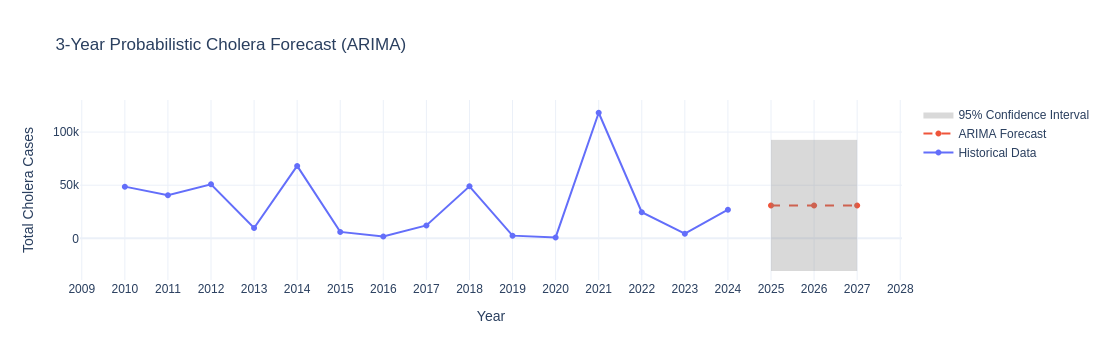

In [39]:
import plotly.graph_objects as go

fig = go.Figure()

# Historical data
fig.add_trace(go.Scatter(
    x=df_year["year"],
    y=df_year["total_cases"],
    mode='lines+markers',
    name='Historical Data'
))

# Forecast mean
fig.add_trace(go.Scatter(
    x=[2025, 2026, 2027],
    y=arima_forecast,
    mode='lines+markers',
    name='ARIMA Forecast',
    line=dict(dash='dash')
))

# Upper confidence bound (invisible line)
fig.add_trace(go.Scatter(
    x=[2025, 2026, 2027],
    y=arima_conf_int[:,1],
    mode='lines',
    line=dict(width=0),
    showlegend=False,
    hoverinfo='skip'
))

# Lower bound with fill (this creates the shaded region)
fig.add_trace(go.Scatter(
    x=[2025, 2026, 2027],
    y=arima_conf_int[:,0],
    mode='lines',
    fill='tonexty',
    fillcolor='rgba(128,128,128,0.3)',
    line=dict(width=0),
    name='95% Confidence Interval'
))

fig.update_layout(
    title="3-Year Probabilistic Cholera Forecast (ARIMA)",
    xaxis_title="Year",
    yaxis_title="Total Cholera Cases",
    hovermode="x unified",
    template="plotly_white"
)

fig.update_xaxes(dtick=1)

fig.show()

9.2 Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import pandas as pd

# Prepare annual data
X_rf = df_year["year"].values.reshape(-1, 1)
y_rf = df_year["total_cases"].values

# Future years
future_years_rf = np.array([2025, 2026, 2027]).reshape(-1, 1)

# Train final Random Forest model on full historical data
rf_final_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_final_model.fit(X_rf, y_rf)

# Forecast future years
rf_forecast = rf_final_model.predict(future_years_rf)

# Store results in a table
rf_forecast_df = pd.DataFrame({
    "year": [2025, 2026, 2027],
    "Random Forest Forecast": rf_forecast
})

print(rf_forecast_df)

9.2.1 Graph Plot for Random Forest Forecast

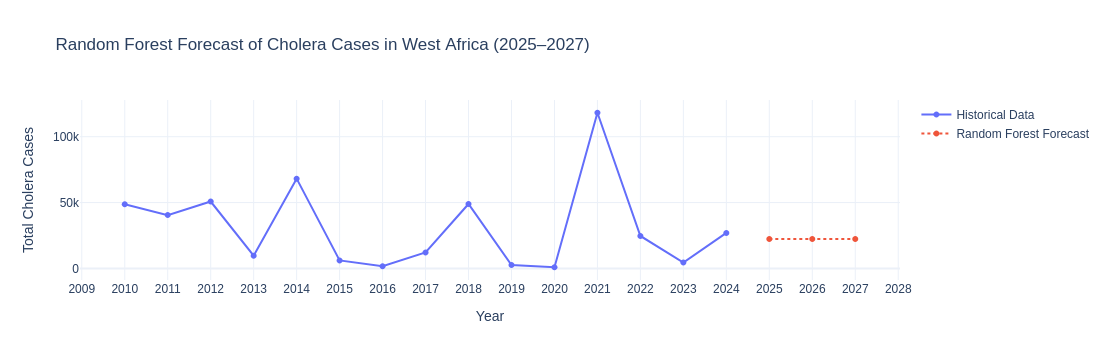

In [34]:
import plotly.graph_objects as go

fig = go.Figure()

# Historical data
fig.add_trace(go.Scatter(
    x=df_year["year"],
    y=df_year["total_cases"],
    mode="lines+markers",
    name="Historical Data"
))

# Random Forest forecast
fig.add_trace(go.Scatter(
    x=[2025, 2026, 2027],
    y=rf_forecast,
    mode="lines+markers",
    name="Random Forest Forecast",
    line=dict(dash="dot")
))

# Layout
fig.update_layout(
    title="Random Forest Forecast of Cholera Cases in West Africa (2025–2027)",
    xaxis_title="Year",
    yaxis_title="Total Cholera Cases",
    template="plotly_white",
    hovermode="x unified"
)

# Force yearly ticks
fig.update_xaxes(dtick=1)

fig.show()

9.3 LSTM

In [27]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

# Prepare annual series
y_lstm = df_year["total_cases"].values.reshape(-1, 1)

# Scale data
scaler = MinMaxScaler(feature_range=(0, 1))
y_scaled = scaler.fit_transform(y_lstm)

# Sequence length
sequence_length = 2

# Create generator for full dataset
generator = TimeseriesGenerator(
    y_scaled,
    y_scaled,
    length=sequence_length,
    batch_size=1
)

# Build final LSTM model
lstm_final_model = Sequential()
lstm_final_model.add(LSTM(50, activation="relu", input_shape=(sequence_length, 1)))
lstm_final_model.add(Dense(1))
lstm_final_model.compile(optimizer="adam", loss="mse")

# Train model on full data
lstm_final_model.fit(generator, epochs=100, verbose=0)

# Forecast next 3 years iteratively
future_steps = 3
lstm_forecast_scaled = []

current_seq = y_scaled[-sequence_length:].copy()

for _ in range(future_steps):
    pred_scaled = lstm_final_model.predict(
        current_seq.reshape(1, sequence_length, 1),
        verbose=0
    )
    lstm_forecast_scaled.append(pred_scaled[0, 0])

    current_seq = np.vstack([current_seq[1:], pred_scaled])

# Convert back to original scale
lstm_forecast_scaled = np.array(lstm_forecast_scaled).reshape(-1, 1)
lstm_forecast = scaler.inverse_transform(lstm_forecast_scaled).flatten()

# Store results in a table
lstm_forecast_df = pd.DataFrame({
    "year": [2025, 2026, 2027],
    "LSTM Forecast": lstm_forecast
})

print(lstm_forecast_df)

   year  LSTM Forecast
0  2025   42590.578125
1  2026   26278.849609
2  2027   26050.181641


9.3.1 Graph Plot for LSTM Forecast

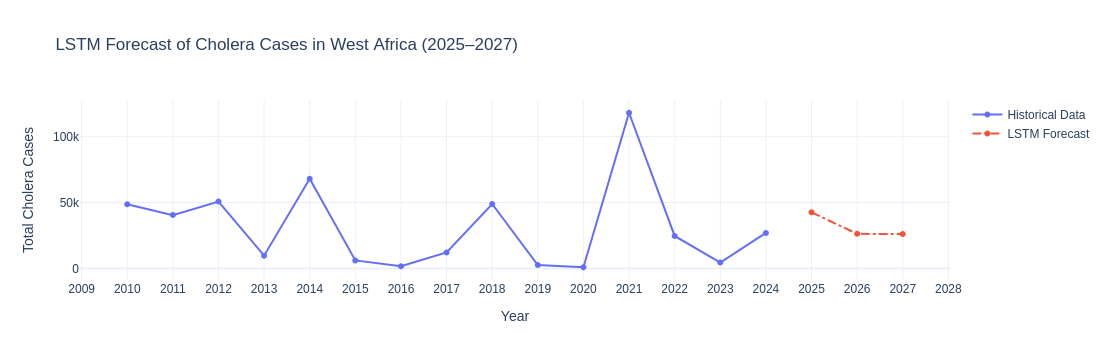

In [35]:
import plotly.graph_objects as go

fig = go.Figure()

# Historical data
fig.add_trace(go.Scatter(
    x=df_year["year"],
    y=df_year["total_cases"],
    mode="lines+markers",
    name="Historical Data"
))

# LSTM forecast
fig.add_trace(go.Scatter(
    x=[2025, 2026, 2027],
    y=lstm_forecast,
    mode="lines+markers",
    name="LSTM Forecast",
    line=dict(dash="dashdot")
))

fig.update_layout(
    title="LSTM Forecast of Cholera Cases in West Africa (2025–2027)",
    xaxis_title="Year",
    yaxis_title="Total Cholera Cases",
    template="plotly_white",
    hovermode="x unified"
)

fig.update_xaxes(dtick=1)

fig.show()

10 Model Graphical Comparisons

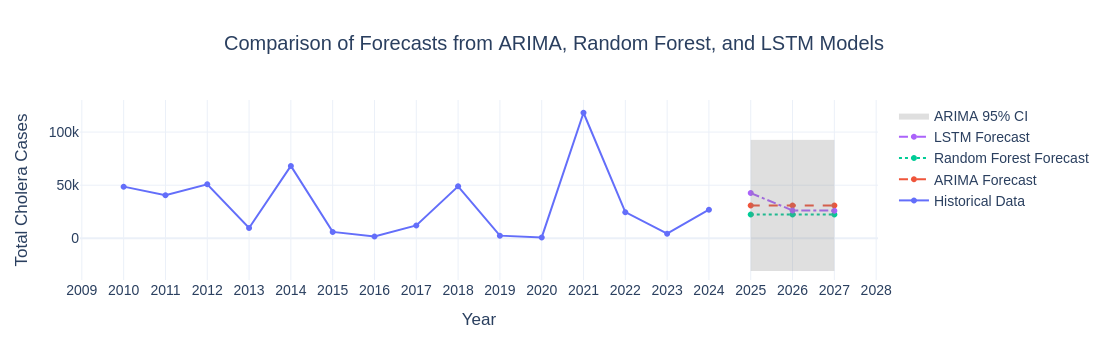

In [40]:
import plotly.graph_objects as go
import numpy as np

future_years = [2025, 2026, 2027]

fig = go.Figure()

# Historical data
fig.add_trace(go.Scatter(
    x=df_year["year"],
    y=df_year["total_cases"],
    mode="lines+markers",
    name="Historical Data"
))

# ARIMA forecast
fig.add_trace(go.Scatter(
    x=future_years,
    y=arima_forecast,
    mode="lines+markers",
    name="ARIMA Forecast",
    line=dict(dash="dash")
))

# Random Forest forecast
fig.add_trace(go.Scatter(
    x=future_years,
    y=rf_forecast,
    mode="lines+markers",
    name="Random Forest Forecast",
    line=dict(dash="dot")
))

# LSTM forecast
fig.add_trace(go.Scatter(
    x=future_years,
    y=lstm_forecast,
    mode="lines+markers",
    name="LSTM Forecast",
    line=dict(dash="dashdot")
))

# ARIMA confidence interval upper bound
fig.add_trace(go.Scatter(
    x=future_years,
    y=arima_conf_int[:, 1],
    mode="lines",
    line=dict(width=0),
    showlegend=False,
    hoverinfo="skip"
))

# ARIMA confidence interval lower bound with fill
fig.add_trace(go.Scatter(
    x=future_years,
    y=arima_conf_int[:, 0],
    mode="lines",
    fill="tonexty",
    fillcolor="rgba(128,128,128,0.25)",
    line=dict(width=0),
    name="ARIMA 95% CI"
))

fig.update_layout(
    title="Comparison of Forecasts from ARIMA, Random Forest, and LSTM Models",
    xaxis_title="Year",
    yaxis_title="Total Cholera Cases",
    hovermode="x unified",
    template="plotly_white",
    title_x=0.5,
    font=dict(size=14)
)

fig.update_xaxes(dtick=1)

fig.show()

10.1 Comparison Table

In [41]:
forecast_table = pd.DataFrame({
    "Year": [2025, 2026, 2027],
    "ARIMA Forecast": arima_forecast,
    "ARIMA Lower 95% CI": arima_conf_int[:, 0],
    "ARIMA Upper 95% CI": arima_conf_int[:, 1],
    "Random Forest Forecast": rf_forecast,
    "LSTM Forecast": lstm_forecast
}).round(2)

print(forecast_table)

            Year  ARIMA Forecast  ARIMA Lower 95% CI  ARIMA Upper 95% CI  \
2025-01-01  2025         30954.6            -30733.1             92642.3   
2026-01-01  2026         30954.6            -30733.1             92642.3   
2027-01-01  2027         30954.6            -30733.1             92642.3   

            Random Forest Forecast  LSTM Forecast  
2025-01-01                22377.88   42590.578125  
2026-01-01                22377.88   26278.849609  
2027-01-01                22377.88   26050.179688  
